In [1]:
# rag_pipeline.py
from typing import Literal
from langgraph.graph import StateGraph, MessagesState, END
from langgraph.prebuilt import tools_condition, ToolNode
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage
from tools import retrieve
from config import llm
from langgraph.checkpoint.memory import MemorySaver

# --- ROUTAGE DES MESSAGES ---
def route_message(state: MessagesState) -> Literal[
    "technical_route", "symptom_route", "simple_route", "off_topic_route", "post_prediction_route"
]:
    """
    Décide quelle route prendre selon le contenu du dernier message utilisateur.
    """
    last_message = state["messages"][-1]
    if not isinstance(last_message, HumanMessage) or not last_message.content.strip():
        return "simple_route"

    content = last_message.content.strip()

    # Cas direct "post-prediction"
    if content.startswith("La maladie détectée est"):
        print("--- ROUTE: POST-PRÉDICTION ---")
        return "post_prediction_route"

    # Classification par le LLM
    classification_prompt = f"""
Vous êtes un classificateur expert. Classez la question de l'utilisateur
en UNE SEULE de ces catégories (réponse uniquement par le mot exact) :

- technical_rice : question technique sur la culture du riz.
- symptom_check : description de symptômes de plants de riz.
- simple : salutation / politesse / conversation basique.
- off_topic : sujet non lié au riz.

Question : "{content}"
"""
    category = llm.invoke(classification_prompt).content.strip().lower()

    if "symptom_check" in category:
        print("--- ROUTE: SYMPTÔMES ---")
        return "symptom_route"
    elif "technical_rice" in category:
        print("--- ROUTE: TECHNIQUE RIZ ---")
        return "technical_route"
    elif "off_topic" in category:
        print("--- ROUTE: HORS SUJET ---")
        return "off_topic_route"
    else:
        print("--- ROUTE: SIMPLE ---")
        return "simple_route"

# --- GÉNÉRATION DES RÉPONSES ---
def generate_simple_response(state: MessagesState):
    """Réponse courte et polie pour les messages simples."""
    last_message = state["messages"][-1]
    response = llm.invoke(f"""
Vous êtes un conseiller amical spécialisé dans le riz.
Répondez poliment et brièvement à :
"{last_message.content}"
""")
    return {"messages": [response]}

def generate_symptom_response(state: MessagesState):
    """Invite l’utilisateur à utiliser l’outil diagnostic."""
    text = (
        "Vous semblez décrire des symptômes sur vos plants de riz."
        "Pour un diagnostic précis, veuillez utiliser l’outil de diagnostic."
    )
    return {"messages": [AIMessage(content=text)]}

def generate_off_topic_response(state: MessagesState):
    """Réponse pré-écrite pour hors sujet."""
    text = (
        "Je suis désolé, mais je suis spécialisé dans la culture du riz. "
        "Comment puis-je vous aider avec votre riziculture aujourd'hui ?"
    )
    return {"messages": [AIMessage(content=text)]}

def query_or_respond(state: MessagesState):
    """Prépare le LLM avec les outils pour les requêtes techniques/post-prédiction."""
    llm_with_tools = llm.bind_tools([retrieve])
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

def generate_technical_response(state: MessagesState):
    """Réponse finale pour une requête technique (avec contexte des outils)."""
    # On récupère le contenu des messages tools
    docs_content = "\n\n".join(
        m.content for m in state["messages"] if getattr(m, "type", None) == "tool"
    )

    system_message_content = (
        "Tu es un conseiller expert en riziculture. Donne des conseils clairs et pratiques.\n\n"
        "Instructions :\n"
        "1. Si la question contient 'La maladie détectée est', adopte un ton d'expert en phytopathologie et structure ainsi :\n"
        "    - Clause de non-responsabilité\n"
        "    - Diagnostic probable\n"
        "    - Facteurs de risque\n"
        "    - Actions correctives\n"
        "    - Stratégies de prévention\n"
        "2. Sinon, donne une réponse complète et claire sur la culture du riz.\n"
        "3. Utilise Markdown pour améliorer la lisibilité.\n\n"
        f"Contexte fourni :\n{docs_content}"
    )

    # Filtrer messages (human + system + AI sans tool_calls)
    conversation_messages = [
        m for m in state["messages"]
        if getattr(m, "type", None) in ("human", "system") or (getattr(m, "type", None) == "ai" and not getattr(m, "tool_calls", None))
    ]
    prompt = [SystemMessage(system_message_content)] + conversation_messages
    response = llm.invoke(prompt)
    return {"messages": [response]}

# --- CONSTRUCTION DU GRAPHE ---
def build_rag_graph():
    graph_builder = StateGraph(MessagesState)

    graph_builder.add_node("simple_response_generator", generate_simple_response)
    graph_builder.add_node("symptom_response_generator", generate_symptom_response)
    graph_builder.add_node("off_topic_response_generator", generate_off_topic_response)
    graph_builder.add_node("query_or_respond", query_or_respond)
    graph_builder.add_node("tools", ToolNode([retrieve]))
    graph_builder.add_node("generate_technical_response", generate_technical_response)

    graph_builder.set_conditional_entry_point(
        route_message,
        {
            "simple_route": "simple_response_generator",
            "symptom_route": "symptom_response_generator",
            "technical_route": "query_or_respond",
            "off_topic_route": "off_topic_response_generator",
            "post_prediction_route": "query_or_respond",
        },
    )

    graph_builder.add_edge("simple_response_generator", END)
    graph_builder.add_edge("symptom_response_generator", END)
    graph_builder.add_edge("off_topic_response_generator", END)

    graph_builder.add_conditional_edges(
        "query_or_respond", tools_condition, {END: END, "tools": "tools"}
    )
    graph_builder.add_edge("tools", "generate_technical_response")
    graph_builder.add_edge("generate_technical_response", END)

    return graph_builder.compile(checkpointer=MemorySaver())


/media/sda1/ispm/l3/annual-project/.venv/lib/python3.12/site-packages/pydantic/main.py:253: UserWarning: WARNING! top_p is not default parameter.
                    top_p was transferred to model_kwargs.
                    Please confirm that top_p is what you intended.
  validated_self = self.__pydantic_validator__.validate_python(data, self_instance=self)


LLM chargé.
HuggingFace cache directory: /home/riandy/.cache/huggingface/transformers


/media/sda1/ispm/l3/annual-project/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


HuggingFace embeddings model chargé.
Chargement des documents de /media/sda1/ispm/l3/annual-project/ml/agrichat/src/../data
Chargement de la BD de /media/sda1/ispm/l3/annual-project/ml/agrichat/src/../data/chroma_langchain_db
Chargement de la base de données vectorielle...
VectorDB chargée.


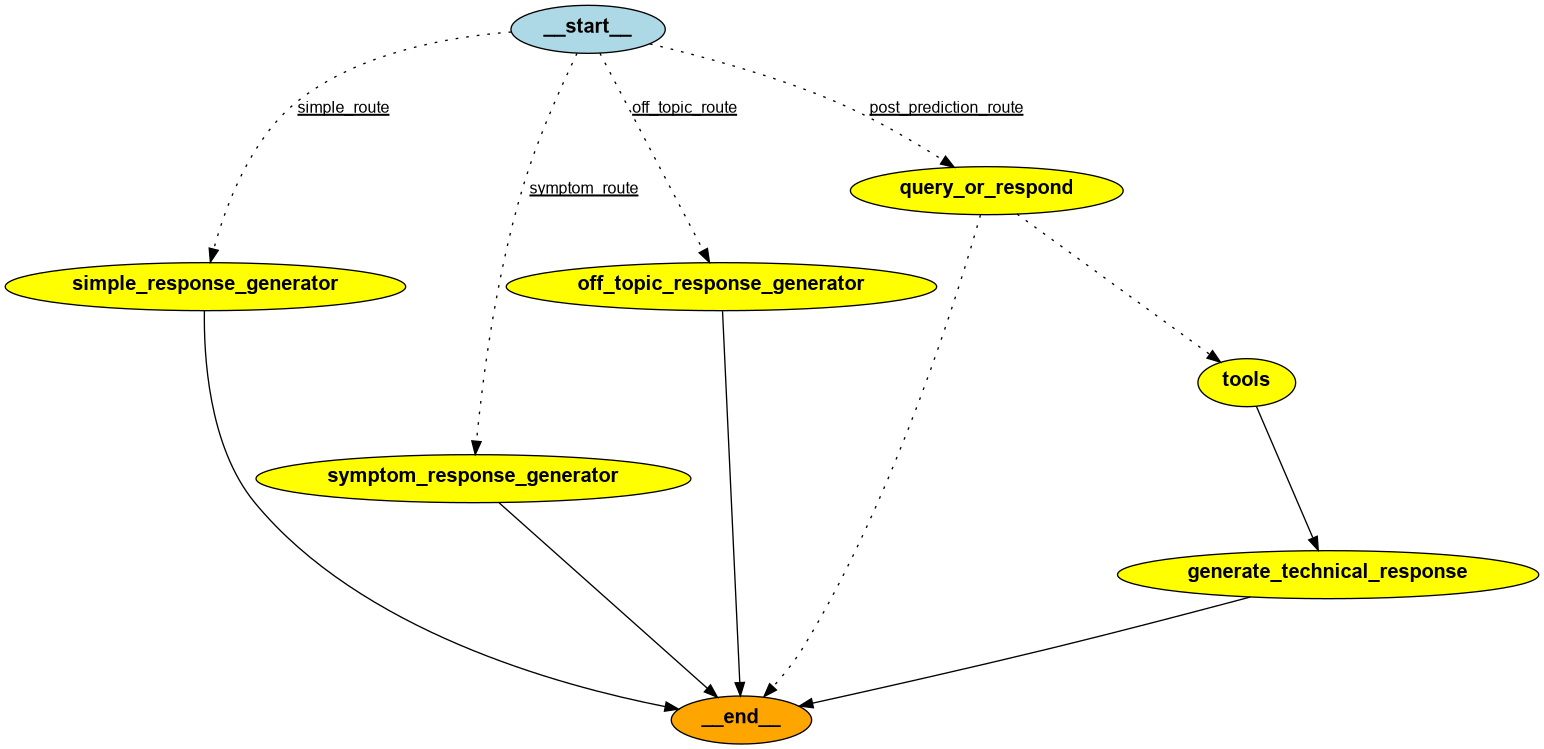

In [2]:
from IPython.display import display, Image
import pygraphviz
graph = build_rag_graph()
try:
    display(Image(graph.get_graph().draw_png()))
except ImportError:
    print(
        "You likely need to install dependencies for pygraphviz, see more here https://github.com/pygraphviz/pygraphviz/blob/main/INSTALL.txt"
    )